In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/context_features_dataset.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,RNF,timestamp,Ambient_Temperature,Load_Density,Humidity,Shift,Day_Type,temp_diff,load_ratio,humidity_impact
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,2025-01-01 00:00:00,26,62,41,Evening,Weekday,10.5,0.62,25.42
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,2025-01-01 00:01:00,39,34,47,Morning,Weekend,10.5,0.34,15.98
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,2025-01-01 00:02:00,34,43,81,Evening,Weekday,10.4,0.43,34.83
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,2025-01-01 00:03:00,30,97,46,Evening,Weekend,10.4,0.97,44.62
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,2025-01-01 00:04:00,27,76,49,Morning,Weekday,10.5,0.76,37.24


In [3]:
print(df.shape)
print(df.columns)

(10000, 23)
Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift',
       'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact'],
      dtype='str')


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
 14  timestamp                10000 non

Dataset inspection completed.
Verified column names and data types.

In [6]:
target = "Machine failure"

print(df[target].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


## Class Distribution Analysis

Target Variable: Machine failure

- 0 = Normal Machine Operation
- 1 = Machine Failure

Class Counts:

| Class | Count |
|---------|---------|
| Normal Operation (0) | 9661 |
| Machine Failure (1) | 339 |

Failure Percentage: 3.39%

Observation:

The dataset is highly imbalanced. Only 3.39% of records correspond to machine failures, while 96.61% represent normal machine operation.

This imbalance can cause machine learning models to favor the majority class and miss failure cases. Therefore, SMOTE (Synthetic Minority Oversampling Technique) will be applied during Week 3 modeling to balance the classes before training.

In [7]:
total = len(df)

failure_count = df["Machine failure"].sum()

failure_percentage = (
    failure_count / total
) * 100

print(f"Total Records: {total}")
print(f"Failure Records: {failure_count}")
print(f"Failure Percentage: {failure_percentage:.2f}%")

Total Records: 10000
Failure Records: 339
Failure Percentage: 3.39%


In [8]:
features = df.drop(columns=["Machine failure"])

features.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp',
       'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type',
       'temp_diff', 'load_ratio', 'humidity_impact'],
      dtype='str')

All remaining columns are candidate features for model training.

In [9]:
df = df.drop(
    columns=["UDI", "Product ID"],
    errors="ignore"
)

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,RNF,timestamp,Ambient_Temperature,Load_Density,Humidity,Shift,Day_Type,temp_diff,load_ratio,humidity_impact
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,...,0,2025-01-01 00:00:00,26,62,41,Evening,Weekday,10.5,0.62,25.42
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,...,0,2025-01-01 00:01:00,39,34,47,Morning,Weekend,10.5,0.34,15.98
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,...,0,2025-01-01 00:02:00,34,43,81,Evening,Weekday,10.4,0.43,34.83
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,...,0,2025-01-01 00:03:00,30,97,46,Evening,Weekend,10.4,0.97,44.62
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,...,0,2025-01-01 00:04:00,27,76,49,Morning,Weekday,10.5,0.76,37.24


In [10]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp',
       'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type',
       'temp_diff', 'load_ratio', 'humidity_impact'],
      dtype='str')

Removed identifier columns because they do not contribute to machine failure prediction.

In [11]:
df.isnull().sum()

Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
timestamp                  0
Ambient_Temperature        0
Load_Density               0
Humidity                   0
Shift                      0
Day_Type                   0
temp_diff                  0
load_ratio                 0
humidity_impact            0
dtype: int64

In [12]:
df.isnull().sum().sum()

np.int64(0)

No missing values detected.

In [13]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [14]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [15]:
failure_percentage = (
    df["Machine failure"].mean()
    * 100
)

print(
    f"Failure Percentage: {failure_percentage:.2f}%"
)

Failure Percentage: 3.39%


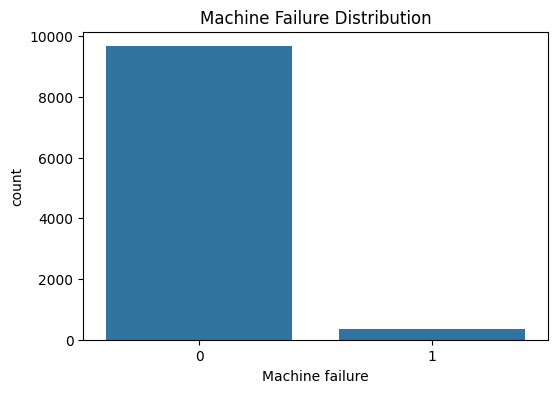

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Machine failure",
    data=df
)

plt.title(
    "Machine Failure Distribution"
)

plt.show()

Observation:

The dataset is highly imbalanced because machine failure cases are much fewer than normal operating cases.

This imbalance can bias machine learning models toward the majority class.

SMOTE will be applied during Week 3 model development to generate synthetic failure samples and improve classification performance.

In [17]:
df.to_csv(
    "../data/modeling_dataset.csv",
    index=False
)

Modeling dataset exported successfully.